# Create input

In [1]:
base_path = "/pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/roms_marbl_dic/"

In [2]:
import xarray as xr

In [3]:
ds_grid = xr.open_dataset("../../INPUT/pacmed12_grd.nc")

In [4]:
ds_tracer_flux_1999 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_1999.nc", decode_timedelta=False)
ds_tracer_flux_2000 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_2000.nc", decode_timedelta=False)
ds_tracer_flux_2021 = xr.open_dataset("../../INPUT/roms_tracer_surf_flux_2021.nc", decode_timedelta=False)

In [5]:
tracer_name = "EC11"

## Surface BGC forcing and passive tracer perturbation

In [6]:
ds_bgc_1999 = xr.open_dataset(f"/pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/INPUT/frc_joined/pacmed12_updtbgcflx_1999_MARBL.nc")
ds_bgc_2000 = xr.open_dataset(f"/pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/INPUT/frc_joined/pacmed12_updtbgcflx_2000_MARBL.nc")
ds_bgc_2021 = xr.open_dataset(f"/pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/INPUT/frc_joined/pacmed12_updtbgcflx_2021_MARBL.nc")

In [7]:
for ds in [ds_bgc_1999, ds_bgc_2000, ds_bgc_2021]:
    ds.attrs = {}

In [8]:
ds_bgc_1999

<xarray.Dataset> Size: 397MB
Dimensions:       (ptime: 12, eta_rho: 962, xi_rho: 1842, dtime: 4, itime: 12)
Dimensions without coordinates: ptime, eta_rho, xi_rho, dtime, itime
Data variables:
    pco2_air      (ptime, eta_rho, xi_rho) float32 85MB ...
    nhy           (dtime, eta_rho, xi_rho) float64 57MB ...
    nox           (dtime, eta_rho, xi_rho) float64 57MB ...
    pco2_time     (ptime) float64 96B ...
    iron          (itime, eta_rho, xi_rho) float32 85MB ...
    pco2_air_alt  (ptime, eta_rho, xi_rho) float32 85MB ...
    nhy_time      (dtime) float64 32B ...
    dust_time     (dtime) float64 32B ...
    iron_time     (itime) float64 96B ...
    nox_time      (dtime) float64 32B ...
    dust          (dtime, eta_rho, xi_rho) float32 28MB ...

### DIC perturbation

In [9]:
ds_tracer_flux_1999

<xarray.Dataset> Size: 7GB
Dimensions:  (time: 20, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time     (time) float64 160B 1.825e+03 1.825e+03 ... 1.826e+03 1.826e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables: (12/25)
    VI7      (time, eta_rho, xi_rho) float64 284MB ...
    VI8      (time, eta_rho, xi_rho) float64 284MB ...
    VI9      (time, eta_rho, xi_rho) float64 284MB ...
    VI10     (time, eta_rho, xi_rho) float64 284MB ...
    VI11     (time, eta_rho, xi_rho) float64 284MB ...
    SS7      (time, eta_rho, xi_rho) float64 284MB ...
    ...       ...
    EC11     (time, eta_rho, xi_rho) float64 284MB ...
    JP7      (time, eta_rho, xi_rho) float64 284MB ...
    JP8      (time, eta_rho, xi_rho) float64 284MB ...
    JP9      (time, eta_rho, xi_rho) float64 284MB ...
    JP10     (time, eta_rho, xi_rho) float64 284MB ...
    JP11     (time, eta_rho, xi_rho) float64 284MB ...

In [10]:
for ds_bgc, ds_tracer_flux in zip([ds_bgc_1999, ds_bgc_2000, ds_bgc_2021], [ds_tracer_flux_1999, ds_tracer_flux_2000, ds_tracer_flux_2021]):
    forcing = ds_tracer_flux[tracer_name].rename({"time": "jtime"})
    time = ds_tracer_flux["time"].rename({"time": "jtime"})

    ds_bgc["DIC_time"] = time
    ds_bgc["DIC"] = -forcing
    ds_bgc["DIC"].attrs = {
                "long_name": "DIC flux into ocean",
                "units": "mmol/m2/s"
    }

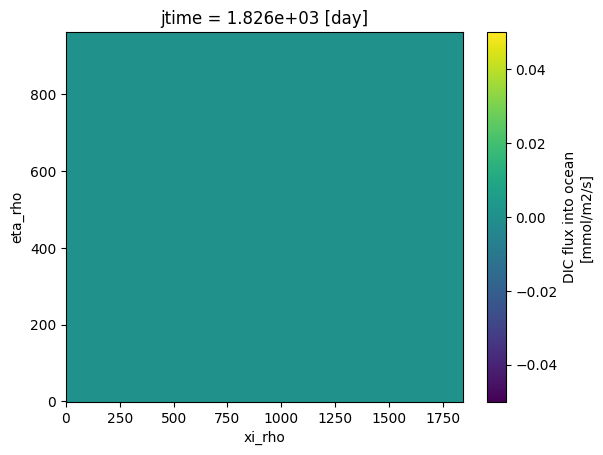

In [11]:
ds_bgc_1999.DIC.isel(jtime=-1).plot()

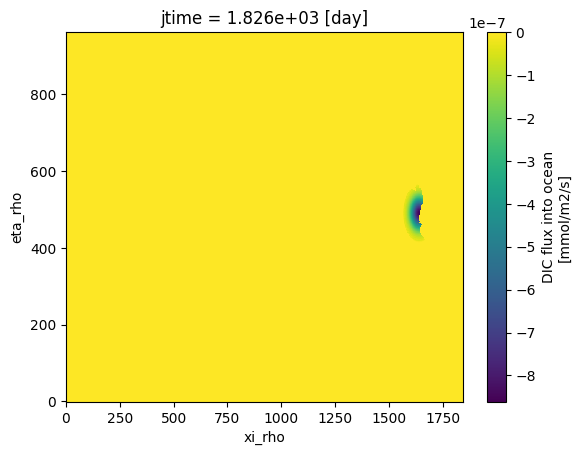

In [12]:
ds_bgc_2000.DIC.isel(jtime=0).plot()

In [13]:
ds_bgc_2021

<xarray.Dataset> Size: 411MB
Dimensions:       (ptime: 12, eta_rho: 962, xi_rho: 1842, dtime: 4, itime: 12,
                   jtime: 1)
Coordinates:
  * jtime         (jtime) float64 8B 9.528e+03
Dimensions without coordinates: ptime, eta_rho, xi_rho, dtime, itime
Data variables: (12/13)
    pco2_air      (ptime, eta_rho, xi_rho) float32 85MB ...
    nhy           (dtime, eta_rho, xi_rho) float64 57MB ...
    nox           (dtime, eta_rho, xi_rho) float64 57MB ...
    pco2_time     (ptime) float64 96B ...
    iron          (itime, eta_rho, xi_rho) float32 85MB ...
    pco2_air_alt  (ptime, eta_rho, xi_rho) float32 85MB ...
    ...            ...
    dust_time     (dtime) float64 32B ...
    iron_time     (itime) float64 96B ...
    nox_time      (dtime) float64 32B ...
    dust          (dtime, eta_rho, xi_rho) float32 28MB ...
    DIC_time      (jtime) float64 8B 9.528e+03
    DIC           (jtime, eta_rho, xi_rho) float64 14MB -0.0 -0.0 ... -0.0 -0.0

In [14]:
from pathlib import Path

In [15]:
outpath = Path(base_path) / f"exp{tracer_name}" / "INPUT" / "roms_frc_bgc_1999.nc"
outpath.parent.mkdir(parents=True, exist_ok=True)
ds_bgc_1999.to_netcdf(outpath)

In [16]:
ds_bgc_2000.to_netcdf(f"{base_path}/exp{tracer_name}/INPUT/roms_frc_bgc_2000.nc")
ds_bgc_2021.to_netcdf(f"{base_path}/exp{tracer_name}/INPUT/roms_frc_bgc_2021.nc")

#### Passive tracer perturbation

In [17]:
ds_1999 = xr.Dataset()
ds_2000 = xr.Dataset()
ds_2021 = xr.Dataset()

In [18]:
for ds, ds_tracer_flux in zip([ds_1999, ds_2000, ds_2021], [ds_tracer_flux_1999, ds_tracer_flux_2000, ds_tracer_flux_2021]):
    forcing = ds_tracer_flux[tracer_name].rename({"time": "jtime"})
    time = ds_tracer_flux["time"].rename({"time": "jtime"})

    ds["time"] = time
    ds["C_CONSERVED_flx"] = -forcing
    ds["C_CONSERVED_flx"].attrs = forcing.attrs

In [19]:
ds_1999

<xarray.Dataset> Size: 284MB
Dimensions:          (jtime: 20, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * jtime            (jtime) float64 160B 1.825e+03 1.825e+03 ... 1.826e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    time             (jtime) float64 160B 1.825e+03 1.825e+03 ... 1.826e+03
    C_CONSERVED_flx  (jtime, eta_rho, xi_rho) float64 284MB -0.0 -0.0 ... -0.0

In [20]:
ds_2000

<xarray.Dataset> Size: 11GB
Dimensions:          (jtime: 764, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * jtime            (jtime) float64 6kB 1.826e+03 1.826e+03 ... 1.858e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    time             (jtime) float64 6kB 1.826e+03 1.826e+03 ... 1.858e+03
    C_CONSERVED_flx  (jtime, eta_rho, xi_rho) float64 11GB -0.0 -0.0 ... -0.0

In [21]:
ds_2021

<xarray.Dataset> Size: 14MB
Dimensions:          (jtime: 1, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * jtime            (jtime) float64 8B 9.528e+03
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    time             (jtime) float64 8B 9.528e+03
    C_CONSERVED_flx  (jtime, eta_rho, xi_rho) float64 14MB -0.0 -0.0 ... -0.0

In [22]:
ds_1999.to_netcdf(f"{base_path}/exp{tracer_name}/INPUT/roms_tracer_surf_flux_1999.nc")
ds_2000.to_netcdf(f"{base_path}/exp{tracer_name}/INPUT/roms_tracer_surf_flux_2000.nc")
ds_2021.to_netcdf(f"{base_path}/exp{tracer_name}/INPUT/roms_tracer_surf_flux_2021.nc")

## Boundary forcing

Simply copy over from roms_marbl_alk:

In [41]:
! cp /pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/roms_marbl_alk/INPUT/roms_bry_tracers.nc /pscratch/sd/n/nloose/DeficitTracer/experiments/pacific/roms_marbl_dic/INPUT/roms_bry_tracers.nc 